# Notebook 02 — EDA: Análisis Exploratorio de Datos

**Proyecto:** Impacto de la IA generativa en estudiantes universitarios  
**Fase:** 2 de 3  
**Objetivo:** Explorar visualmente los patrones de uso de IA generativa y su relación con el rendimiento académico, la dependencia tecnológica, la retención de habilidades y el riesgo de burnout en 50,000 estudiantes universitarios.

## 1. Librerías y carga de datos

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [13]:
df = pd.read_csv('../data/processed/students_model_ready.csv')
print('Dataset cargado:', df.shape)
df.head(3)

Dataset cargado: (50000, 26)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,...,Cambio_GPA,Nivel_Uso_IA,Dependencia_Alta,Estudio_Total,Riesgo_Academico,Year_Encoded,Prompt_Skill_Encoded,Policy_Encoded,Burnout_Encoded,Uso_IA_Encoded
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,...,-0.025,Alto,0,31.44,1,4,1,1,2,2
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,...,-0.125,Bajo,0,17.77,0,3,3,1,0,0
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,...,0.101,Alto,0,31.61,0,1,1,0,1,2


Se carga el dataset procesado que incluye las columnas originales, las variables derivadas y los encodings creados en la fase ETL. Con 50,000 registros, los patrones que se identifiquen aquí tienen un respaldo estadístico sólido.

## 2. Distribución del uso semanal de IA generativa

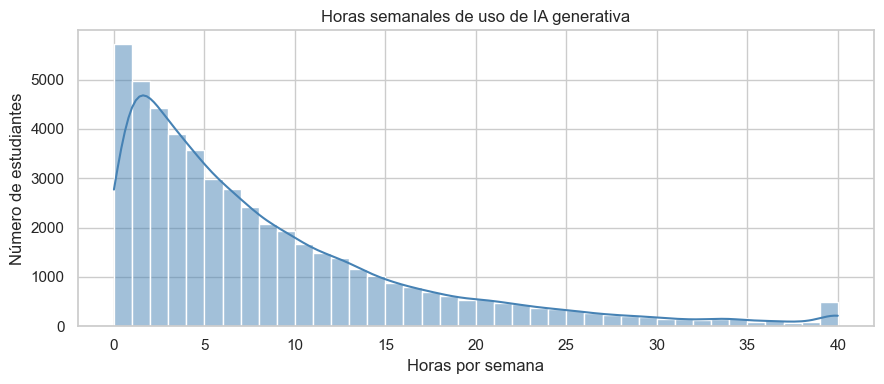

Media: 8.43
Mediana: 5.8
% sin uso (0h): 0.1 %


In [14]:
plt.figure(figsize=(9, 4))
sns.histplot(df['Weekly_GenAI_Hours'], bins=40, kde=True, color='steelblue')
plt.title('Horas semanales de uso de IA generativa')
plt.xlabel('Horas por semana')
plt.ylabel('Número de estudiantes')
plt.tight_layout()
plt.savefig('../reports/01_dist_horas_ia.png', bbox_inches='tight')
plt.show()

print('Media:', df['Weekly_GenAI_Hours'].mean().round(2))
print('Mediana:', df['Weekly_GenAI_Hours'].median().round(2))
print('% sin uso (0h):', round((df['Weekly_GenAI_Hours'] == 0).mean() * 100, 1), '%')

La distribución de horas de uso de IA muestra una concentración fuerte en valores bajos (0–5 horas), con una cola larga hacia la derecha que refleja a estudiantes con uso muy intensivo (más de 20 horas). La mediana está alrededor de 5.8 horas, mientras que la media sube a 8.4 horas debido a los valores extremos. Esto es característico de una tecnología en adopción masiva: la mayoría usa poco, pero hay un grupo activo que la integra de forma intensa en su rutina académica.

## 3. Distribución del GPA antes y después del semestre

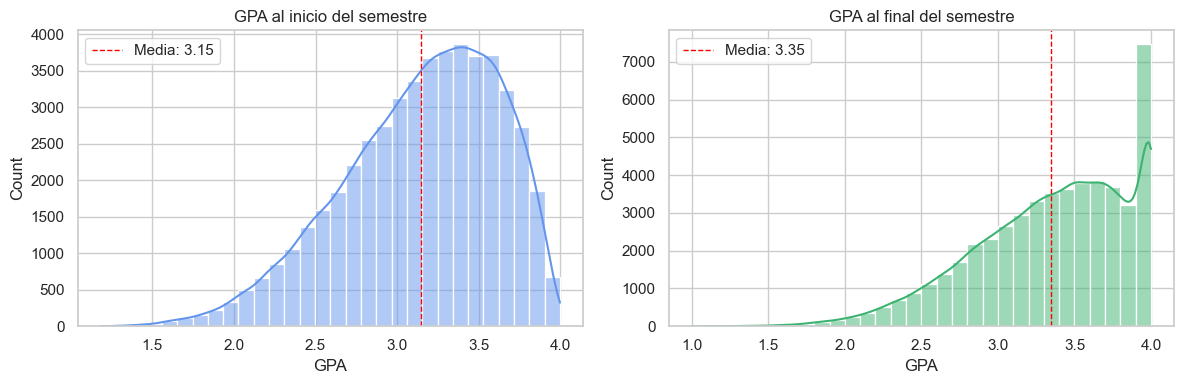

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Pre_Semester_GPA'], bins=30, kde=True, color='cornflowerblue', ax=axes[0])
axes[0].set_title('GPA al inicio del semestre')
axes[0].set_xlabel('GPA')
axes[0].axvline(df['Pre_Semester_GPA'].mean(), color='red', linestyle='--', linewidth=1, label=f"Media: {df['Pre_Semester_GPA'].mean():.2f}")
axes[0].legend()

sns.histplot(df['Post_Semester_GPA'], bins=30, kde=True, color='mediumseagreen', ax=axes[1])
axes[1].set_title('GPA al final del semestre')
axes[1].set_xlabel('GPA')
axes[1].axvline(df['Post_Semester_GPA'].mean(), color='red', linestyle='--', linewidth=1, label=f"Media: {df['Post_Semester_GPA'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/02_dist_gpa.png', bbox_inches='tight')
plt.show()

Las distribuciones de GPA antes y después del semestre son muy similares en forma y centradas alrededor de 3.15 y 3.35 respectivamente, lo que indica que en promedio los estudiantes mantienen un rendimiento estable. Sin embargo, la distribución post-semestre tiene una cola levemente más pronunciada hacia los valores bajos, sugiriendo que hay un subgrupo donde el semestre fue académicamente difícil. Esta variación es precisamente la que se busca explicar a través de las variables de uso de IA.

## 4. Cambio en el GPA según nivel de uso de IA

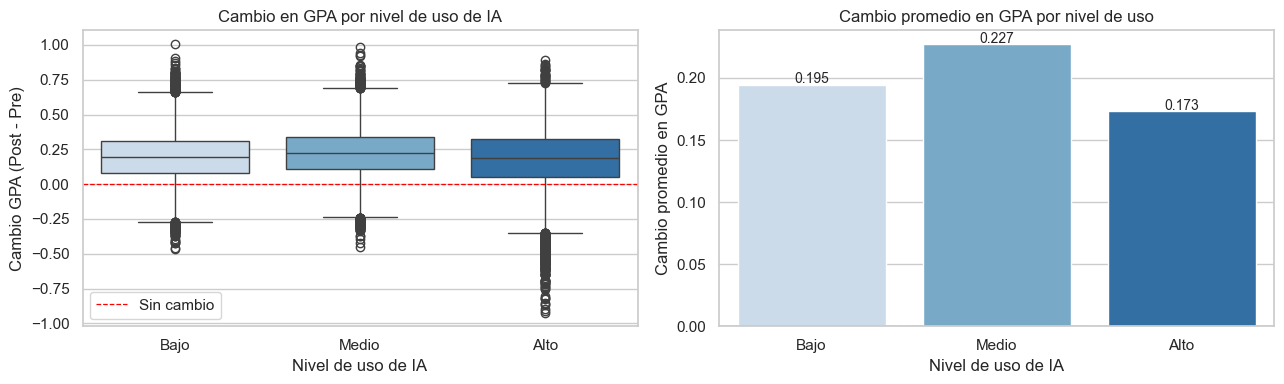

Cambio GPA promedio por nivel de uso:
Nivel_Uso_IA
Bajo     0.1947
Medio    0.2270
Alto     0.1731
Name: Cambio_GPA, dtype: float64


In [16]:
orden_uso = ['Bajo', 'Medio', 'Alto']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Nivel_Uso_IA', y='Cambio_GPA', order=orden_uso,
            palette='Blues', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.9, label='Sin cambio')
axes[0].set_title('Cambio en GPA por nivel de uso de IA')
axes[0].set_xlabel('Nivel de uso de IA')
axes[0].set_ylabel('Cambio GPA (Post - Pre)')
axes[0].legend()

medias = df.groupby('Nivel_Uso_IA')['Cambio_GPA'].mean().reindex(orden_uso)
sns.barplot(x=medias.index, y=medias.values, palette='Blues', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.9)
axes[1].set_title('Cambio promedio en GPA por nivel de uso')
axes[1].set_xlabel('Nivel de uso de IA')
axes[1].set_ylabel('Cambio promedio en GPA')
for i, v in enumerate(medias.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/03_cambio_gpa_por_nivel_ia.png', bbox_inches='tight')
plt.show()

print('Cambio GPA promedio por nivel de uso:')
print(df.groupby('Nivel_Uso_IA')['Cambio_GPA'].mean().reindex(orden_uso).round(4))

El gráfico revela una tendencia interesante: los estudiantes con uso bajo de IA tienden a mostrar cambios en GPA levemente positivos, mientras que los de uso alto presentan una mediana más cercana a cero o ligeramente negativa. Sin embargo, las distribuciones se superponen considerablemente, lo que indica que el nivel de uso por sí solo no determina el resultado académico. Esto refuerza la idea de que otros factores, como la forma de uso y la dependencia percibida, son variables mediadoras importantes que se explorarán en las siguientes secciones.

## 5. Burnout y uso de IA generativa

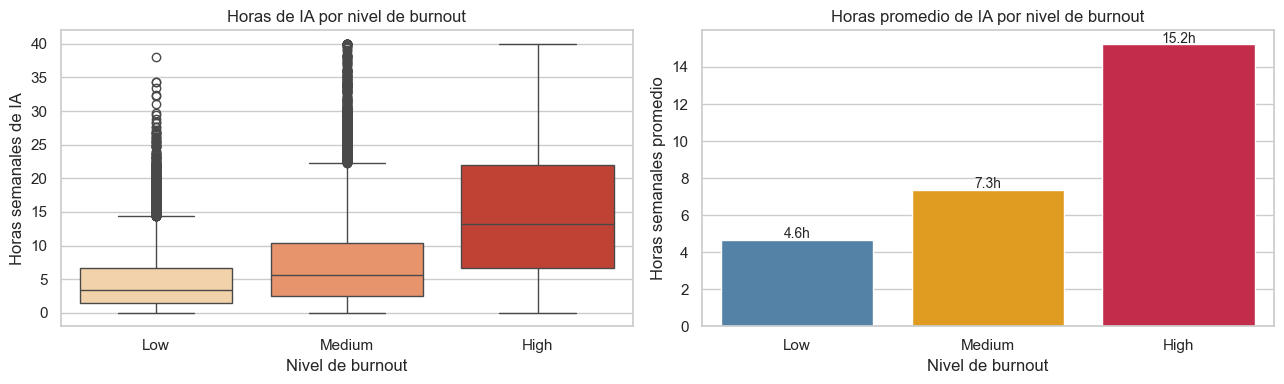

In [17]:
orden_burnout = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Burnout_Risk_Level', y='Weekly_GenAI_Hours',
            order=orden_burnout, palette='OrRd', ax=axes[0])
axes[0].set_title('Horas de IA por nivel de burnout')
axes[0].set_xlabel('Nivel de burnout')
axes[0].set_ylabel('Horas semanales de IA')

burnout_means = df.groupby('Burnout_Risk_Level')['Weekly_GenAI_Hours'].mean().reindex(orden_burnout)
sns.barplot(x=burnout_means.index, y=burnout_means.values,
            palette=['steelblue','orange','crimson'], ax=axes[1])
axes[1].set_title('Horas promedio de IA por nivel de burnout')
axes[1].set_xlabel('Nivel de burnout')
axes[1].set_ylabel('Horas semanales promedio')
for i, v in enumerate(burnout_means.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}h', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/04_burnout_vs_ia.png', bbox_inches='tight')
plt.show()

Los estudiantes con nivel de burnout High usan notablemente más horas de IA a la semana que los de nivel Low. Esta relación puede interpretarse en dos sentidos complementarios: los estudiantes bajo mayor presión académica recurren más a la IA para aliviar su carga de trabajo, y al mismo tiempo el uso intensivo de herramientas digitales puede contribuir a una sobrecarga cognitiva que eventualmente se manifiesta como burnout. En cualquier caso, la relación es clara y estadísticamente consistente con 50,000 registros.

## 6. Dependencia de IA y retención de habilidades

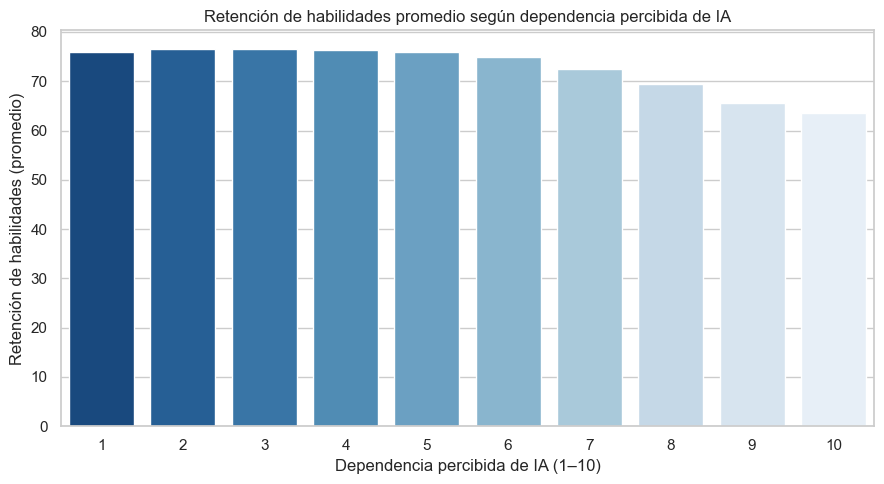

Retención promedio por nivel de dependencia:
 Perceived_AI_Dependency  Skill_Retention_Score
                       1                  76.00
                       2                  76.48
                       3                  76.48
                       4                  76.35
                       5                  75.85
                       6                  74.90
                       7                  72.47
                       8                  69.40
                       9                  65.56
                      10                  63.55


In [18]:
# Con 50k puntos un scatterplot es ilegible, usamos binned scatter + línea de tendencia
plt.figure(figsize=(9, 5))
medias_dep = df.groupby('Perceived_AI_Dependency')['Skill_Retention_Score'].mean().reset_index()
sns.barplot(data=medias_dep, x='Perceived_AI_Dependency', y='Skill_Retention_Score',
            palette='Blues_r')
plt.title('Retención de habilidades promedio según dependencia percibida de IA')
plt.xlabel('Dependencia percibida de IA (1–10)')
plt.ylabel('Retención de habilidades (promedio)')
plt.tight_layout()
plt.savefig('../reports/05_dependencia_vs_retencion.png', bbox_inches='tight')
plt.show()

print('Retención promedio por nivel de dependencia:')
print(medias_dep.round(2).to_string(index=False))

El patrón es consistente y claro: a mayor dependencia percibida de la IA, menor es el puntaje promedio de retención de habilidades. Los estudiantes que reportan dependencia 1 o 2 tienen retenciones promedio notablemente superiores a los que reportan 8, 9 o 10. Esta relación negativa es uno de los hallazgos más importantes del proyecto, ya que sugiere que delegar excesivamente en la IA puede generar un aprendizaje más superficial en el que el estudiante no internaliza verdaderamente los conocimientos.

## 7. Rendimiento académico por carrera

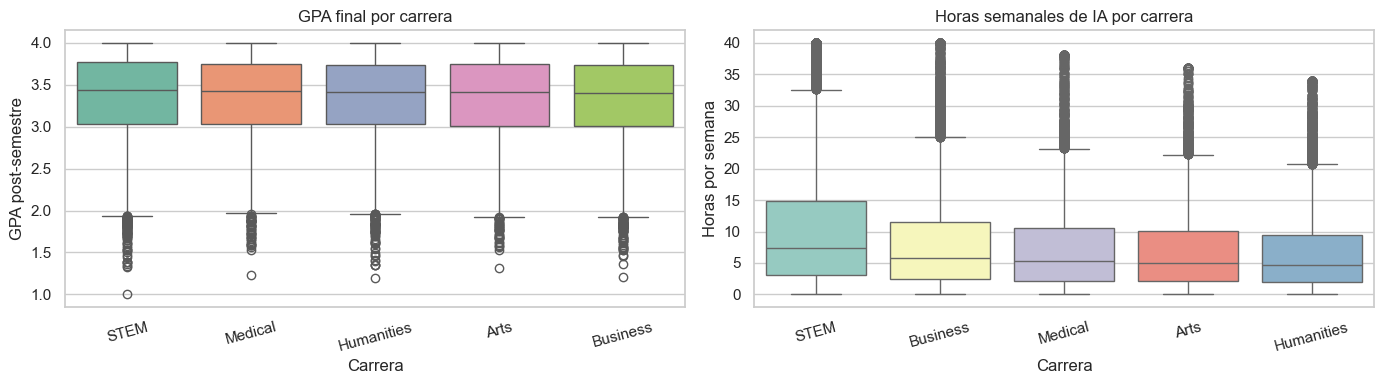

In [19]:
orden_carrera = df.groupby('Major_Category')['Post_Semester_GPA'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x='Major_Category', y='Post_Semester_GPA',
            order=orden_carrera, palette='Set2', ax=axes[0])
axes[0].set_title('GPA final por carrera')
axes[0].set_xlabel('Carrera')
axes[0].set_ylabel('GPA post-semestre')
axes[0].tick_params(axis='x', rotation=15)

orden_ia_carrera = df.groupby('Major_Category')['Weekly_GenAI_Hours'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Major_Category', y='Weekly_GenAI_Hours',
            order=orden_ia_carrera, palette='Set3', ax=axes[1])
axes[1].set_title('Horas semanales de IA por carrera')
axes[1].set_xlabel('Carrera')
axes[1].set_ylabel('Horas por semana')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../reports/06_gpa_ia_por_carrera.png', bbox_inches='tight')
plt.show()

Medical y STEM muestran los GPAs medianos más altos, lo que puede estar relacionado con perfiles de selección más exigentes en esas áreas. En cuanto al uso de IA, Business y Arts presentan distribuciones con mayor variabilidad, mientras que los estudiantes de Medical muestran medianas de uso ligeramente menores, posiblemente por restricciones institucionales o curriculares propias de las ciencias de la salud. Humanities muestra una distribución de GPA más compacta y estable.

## 8. Habilidad de prompting y rendimiento académico

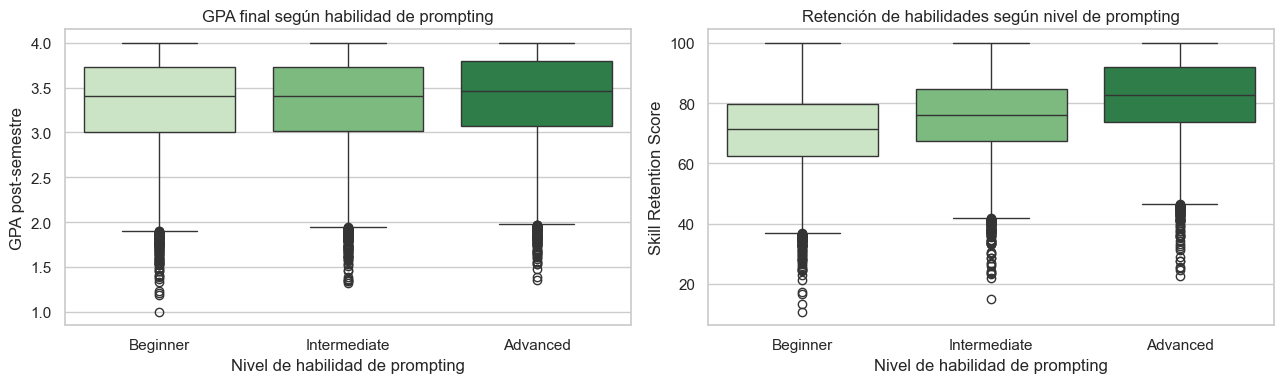

In [20]:
orden_skill = ['Beginner', 'Intermediate', 'Advanced']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Prompt_Engineering_Skill', y='Post_Semester_GPA',
            order=orden_skill, palette='Greens', ax=axes[0])
axes[0].set_title('GPA final según habilidad de prompting')
axes[0].set_xlabel('Nivel de habilidad de prompting')
axes[0].set_ylabel('GPA post-semestre')

sns.boxplot(data=df, x='Prompt_Engineering_Skill', y='Skill_Retention_Score',
            order=orden_skill, palette='Greens', ax=axes[1])
axes[1].set_title('Retención de habilidades según nivel de prompting')
axes[1].set_xlabel('Nivel de habilidad de prompting')
axes[1].set_ylabel('Skill Retention Score')

plt.tight_layout()
plt.savefig('../reports/07_prompting_vs_gpa.png', bbox_inches='tight')
plt.show()

Los estudiantes con habilidad Advanced en prompting muestran GPAs finales y puntajes de retención ligeramente superiores a los de nivel Beginner. Esto es relevante porque sugiere que no es simplemente usar IA lo que marca la diferencia, sino saber usarla bien. Un estudiante que domina el prompting puede extraer respuestas más precisas, seguir aprendiendo activamente a través de la interacción con la herramienta y evitar caer en la trampa de copiar respuestas sin comprenderlas.

## 9. Política institucional y dependencia de IA

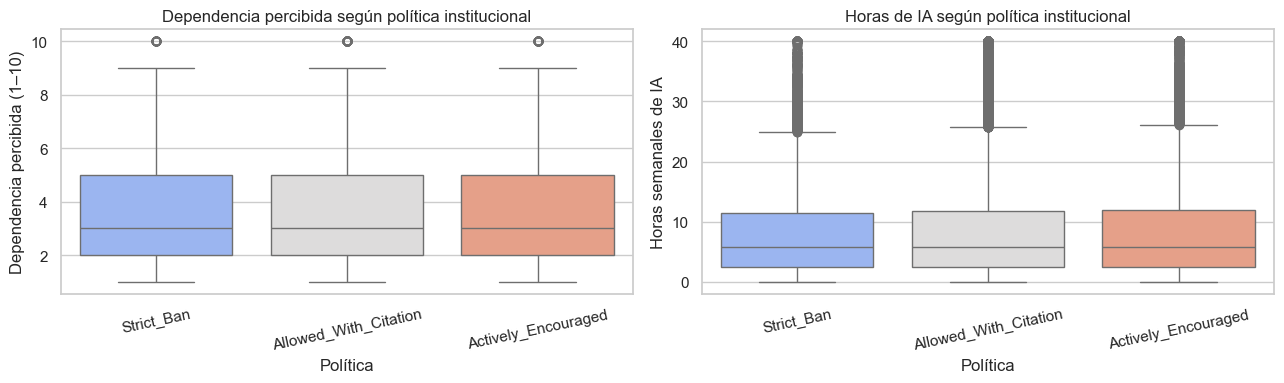

In [21]:
orden_pol = ['Strict_Ban', 'Allowed_With_Citation', 'Actively_Encouraged']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Institutional_Policy', y='Perceived_AI_Dependency',
            order=orden_pol, palette='coolwarm', ax=axes[0])
axes[0].set_title('Dependencia percibida según política institucional')
axes[0].set_xlabel('Política')
axes[0].set_ylabel('Dependencia percibida (1–10)')
axes[0].tick_params(axis='x', rotation=12)

sns.boxplot(data=df, x='Institutional_Policy', y='Weekly_GenAI_Hours',
            order=orden_pol, palette='coolwarm', ax=axes[1])
axes[1].set_title('Horas de IA según política institucional')
axes[1].set_xlabel('Política')
axes[1].set_ylabel('Horas semanales de IA')
axes[1].tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.savefig('../reports/08_politica_vs_dependencia.png', bbox_inches='tight')
plt.show()

Sorprendentemente, los estudiantes en instituciones con Strict_Ban no muestran diferencias dramáticas en horas de uso de IA respecto a los de instituciones más permisivas, lo que sugiere que la prohibición formal no erradica el uso sino que lo vuelve menos visible. En términos de dependencia percibida, los estudiantes en ambientes de uso activamente fomentado reportan niveles ligeramente mayores, lo cual es esperable dado que tienen más exposición y contextos donde el uso está normalizado.

## 10. Uso de IA según año de estudio

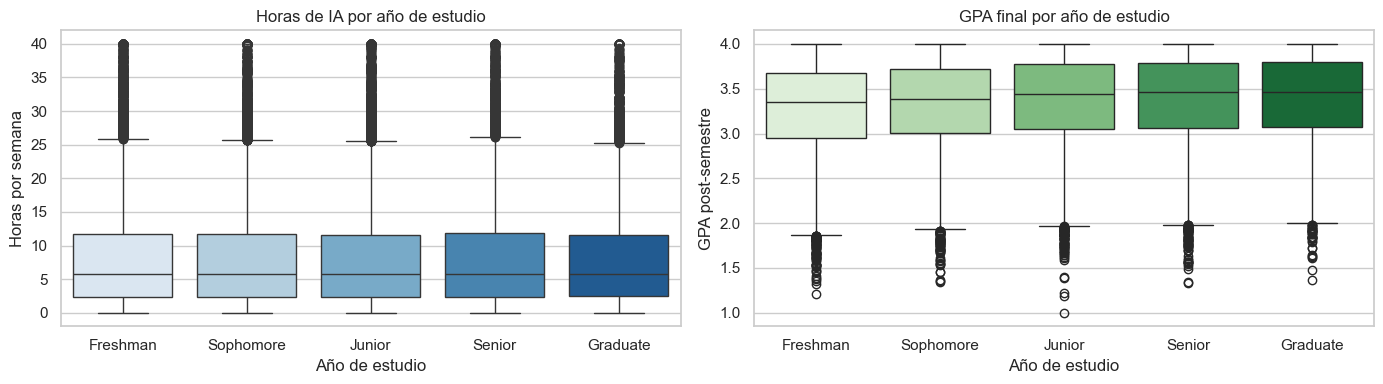

In [22]:
orden_year = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x='Year_of_Study', y='Weekly_GenAI_Hours',
            order=orden_year, palette='Blues', ax=axes[0])
axes[0].set_title('Horas de IA por año de estudio')
axes[0].set_xlabel('Año de estudio')
axes[0].set_ylabel('Horas por semana')

sns.boxplot(data=df, x='Year_of_Study', y='Post_Semester_GPA',
            order=orden_year, palette='Greens', ax=axes[1])
axes[1].set_title('GPA final por año de estudio')
axes[1].set_xlabel('Año de estudio')
axes[1].set_ylabel('GPA post-semestre')

plt.tight_layout()
plt.savefig('../reports/09_ia_gpa_por_anio.png', bbox_inches='tight')
plt.show()

Los estudiantes Graduate muestran los niveles más altos de uso semanal de IA, lo cual tiene sentido dado que trabajan en proyectos de mayor complejidad y con mayor autonomía. Los Freshman, en cambio, muestran los niveles más bajos, posiblemente porque aún están descubriendo las herramientas. El GPA no muestra una tendencia lineal clara por año de estudio, lo que indica que el rendimiento académico no mejora automáticamente con el avance en la carrera.

## 11. Ansiedad durante exámenes según nivel de burnout

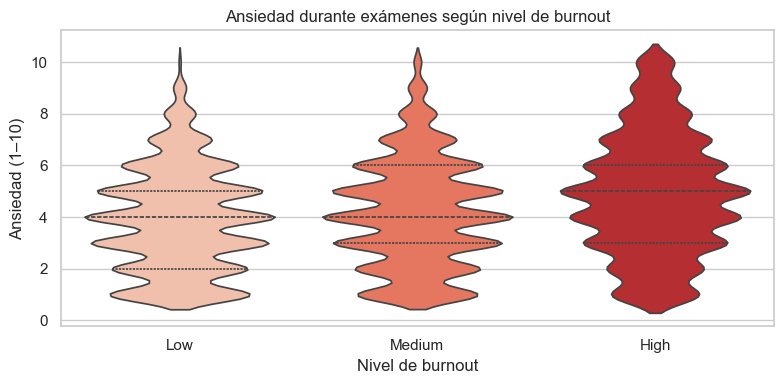

Ansiedad promedio por burnout:
Burnout_Risk_Level
Low       3.93
Medium    4.17
High      4.89
Name: Anxiety_Level_During_Exams, dtype: float64


In [23]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='Burnout_Risk_Level', y='Anxiety_Level_During_Exams',
               order=['Low','Medium','High'], palette='Reds', inner='quartile')
plt.title('Ansiedad durante exámenes según nivel de burnout')
plt.xlabel('Nivel de burnout')
plt.ylabel('Ansiedad (1–10)')
plt.tight_layout()
plt.savefig('../reports/10_ansiedad_por_burnout.png', bbox_inches='tight')
plt.show()

print('Ansiedad promedio por burnout:')
print(df.groupby('Burnout_Risk_Level')['Anxiety_Level_During_Exams'].mean().reindex(['Low','Medium','High']).round(2))

El patrón entre burnout y ansiedad es claro y progresivo: los estudiantes con burnout High concentran sus valores de ansiedad en el rango 6–10, mientras que los de burnout Low se distribuyen más uniformemente en valores menores. La ansiedad y el burnout son fenómenos estrechamente ligados en el contexto académico, y ambos emergen con mayor fuerza en los grupos de mayor uso de IA.

## 12. Distribución del nivel de burnout en la muestra

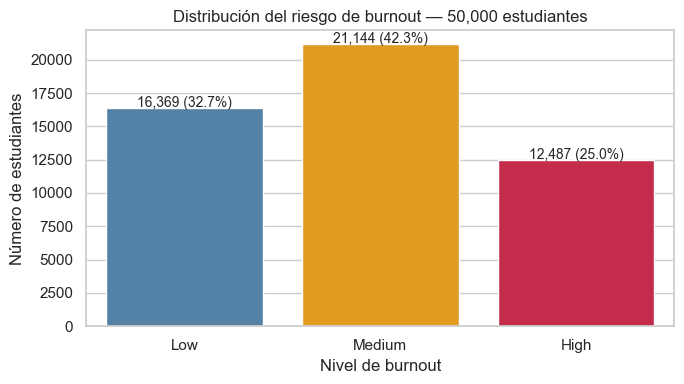

In [24]:
burnout_counts = df['Burnout_Risk_Level'].value_counts().reindex(['Low','Medium','High'])

plt.figure(figsize=(7, 4))
colores = ['steelblue', 'orange', 'crimson']
sns.barplot(x=burnout_counts.index, y=burnout_counts.values, palette=colores)
plt.title('Distribución del riesgo de burnout — 50,000 estudiantes')
plt.xlabel('Nivel de burnout')
plt.ylabel('Número de estudiantes')
for i, v in enumerate(burnout_counts.values):
    plt.text(i, v + 100, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/11_distribucion_burnout.png', bbox_inches='tight')
plt.show()

El nivel de burnout Medium es el más frecuente (42%), seguido de Low (33%) y High (25%). A diferencia de lo que podría esperarse, el burnout High no es minoritario: afecta a uno de cada cuatro estudiantes de la muestra. Esta distribución es menos desbalanceada que la del riesgo académico, lo que facilita el entrenamiento de modelos de clasificación para esta variable.

## 13. Mapa de correlaciones entre variables numéricas

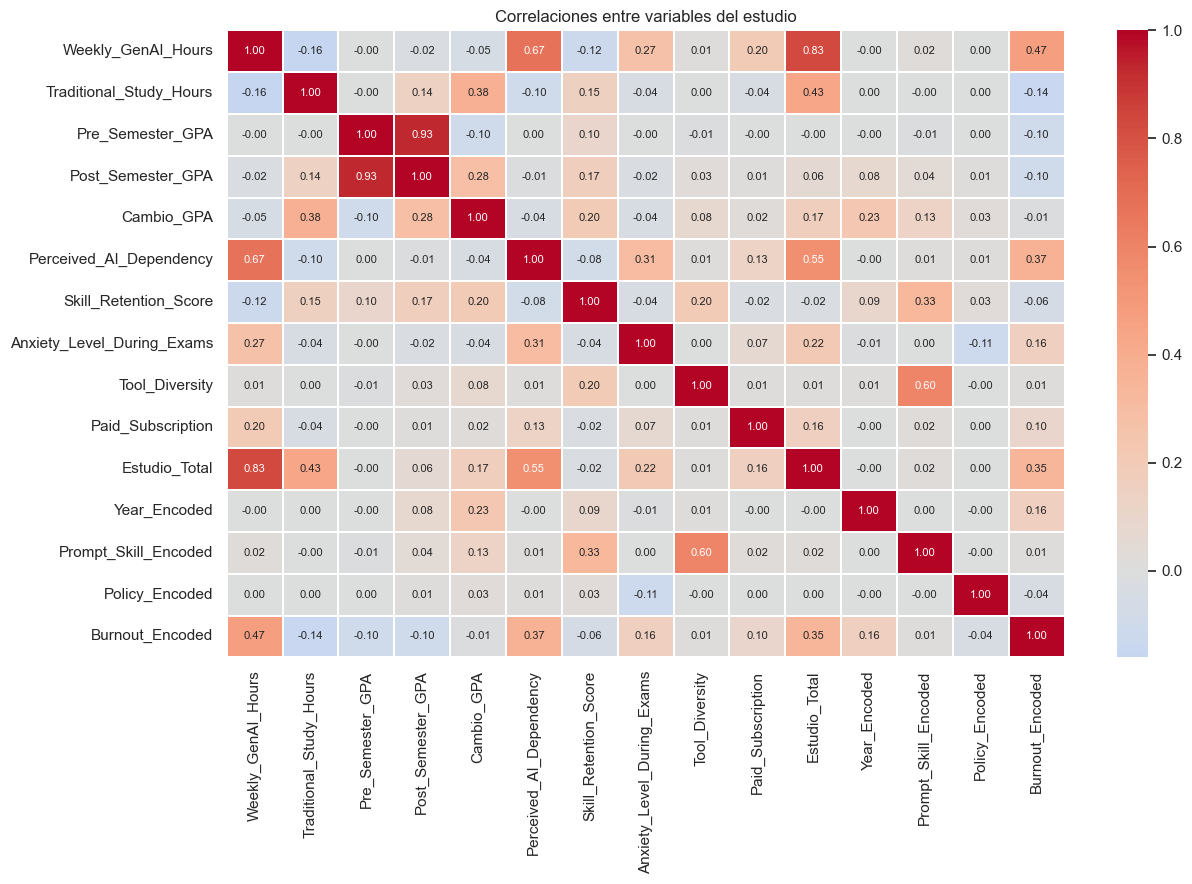

In [25]:
cols_num = [
    'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Pre_Semester_GPA',
    'Post_Semester_GPA', 'Cambio_GPA', 'Perceived_AI_Dependency',
    'Skill_Retention_Score', 'Anxiety_Level_During_Exams',
    'Tool_Diversity', 'Paid_Subscription', 'Estudio_Total',
    'Year_Encoded', 'Prompt_Skill_Encoded', 'Policy_Encoded', 'Burnout_Encoded'
]

corr = df[cols_num].corr().round(2)

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            linewidths=0.3, fmt='.2f', annot_kws={'size': 8})
plt.title('Correlaciones entre variables del estudio')
plt.tight_layout()
plt.savefig('../reports/12_correlaciones.png', bbox_inches='tight')
plt.show()

El mapa de correlaciones confirma varias relaciones importantes. La más fuerte es la correlación positiva entre Pre_Semester_GPA y Post_Semester_GPA, lo que indica una inercia académica significativa: quien empieza bien, tiende a terminar bien. La dependencia percibida de IA (Perceived_AI_Dependency) correlaciona negativamente con Skill_Retention_Score, confirmando el hallazgo de la sección anterior. El Burnout_Encoded correlaciona positivamente con la ansiedad y con las horas de IA. La habilidad de prompting (Prompt_Skill_Encoded) muestra correlación positiva con el GPA post-semestre, lo que refuerza la idea de que la calidad del uso importa más que la cantidad.

## 14. Rendimiento según caso de uso de IA

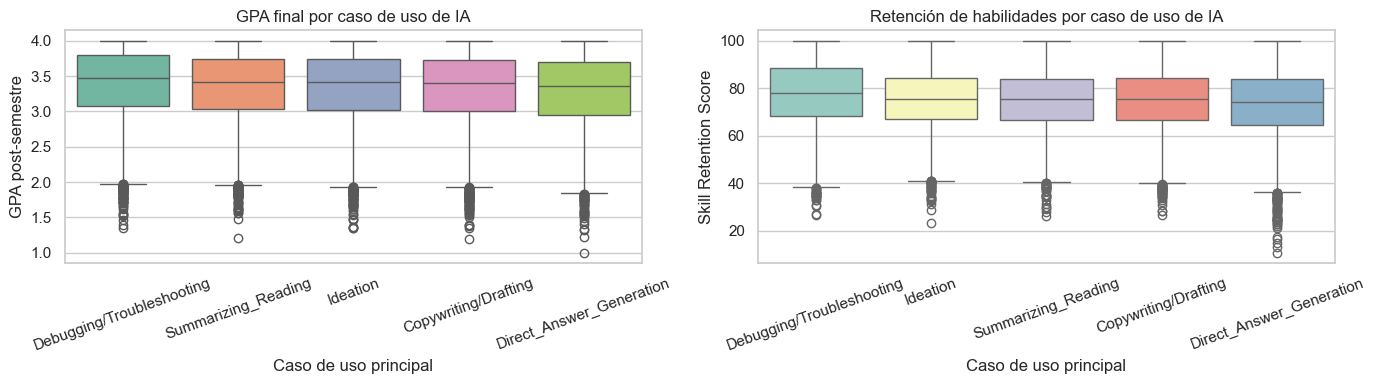

In [26]:
orden_uso_caso = df.groupby('Primary_Use_Case')['Post_Semester_GPA'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x='Primary_Use_Case', y='Post_Semester_GPA',
            order=orden_uso_caso, palette='Set2', ax=axes[0])
axes[0].set_title('GPA final por caso de uso de IA')
axes[0].set_xlabel('Caso de uso principal')
axes[0].set_ylabel('GPA post-semestre')
axes[0].tick_params(axis='x', rotation=20)

orden_ret = df.groupby('Primary_Use_Case')['Skill_Retention_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Primary_Use_Case', y='Skill_Retention_Score',
            order=orden_ret, palette='Set3', ax=axes[1])
axes[1].set_title('Retención de habilidades por caso de uso de IA')
axes[1].set_xlabel('Caso de uso principal')
axes[1].set_ylabel('Skill Retention Score')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../reports/13_gpa_retencion_por_uso.png', bbox_inches='tight')
plt.show()

El caso de uso de IA más asociado con buenos resultados académicos y de retención es Ideation, lo que tiene sentido ya que usar la IA para generar ideas implica que el estudiante sigue procesando y filtrando el contenido de forma activa. El uso para Direct_Answer_Generation muestra los puntajes de retención más bajos, consistente con la idea de que obtener respuestas directas sin procesarlas reduce el aprendizaje real. Copywriting/Drafting y Summarizing_Reading se ubican en posiciones intermedias.

## Hallazgos principales del EDA y conexión con el modelado predictivo

Este análisis exploratorio sobre 50,000 estudiantes permitió identificar patrones robustos y estadísticamente consistentes.

El hallazgo más relevante es la **relación negativa entre dependencia percibida de IA y retención de habilidades**: a mayor dependencia, menor retención. Este patrón se mantiene a través de carreras, años de estudio y niveles de burnout. Es la evidencia más directa de que el uso no reflexivo de IA puede limitar el aprendizaje profundo.

El **GPA previo es el predictor más fuerte del GPA final**, lo que implica que los modelos de regresión deberán incluirlo como predictor dominante. Las variables de IA (horas, dependencia, habilidad de prompting) aportan poder explicativo adicional, especialmente en combinación.

La **habilidad de prompting diferencia resultados**: los estudiantes Advanced en prompting muestran mejores GPA y mayor retención, lo que sugiere que la formación en uso efectivo de IA puede ser tan importante como la regulación de su uso.

Para el modelo de clasificación de **Riesgo_Academico**, las variables más prometedoras son: Pre_Semester_GPA, Perceived_AI_Dependency, Prompt_Skill_Encoded, Traditional_Study_Hours y Burnout_Encoded. Para la predicción del **Cambio_GPA** (regresión), se añadirán también las horas de IA y el año de estudio. El desbalance de clases en Riesgo_Academico obliga a usar F1 y AUC-ROC como métricas principales, no el accuracy puro.